# Load your final dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

df = pd.read_csv("smartcare_final_preprocessed_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (800, 45)


,numerical__age,numerical__waiting_days,numerical__previous_appointments,numerical__missed_previous_appointments,numerical__previous_missed_rate,numerical__has_previous_appointment,numerical__appointment_month,numerical__appointment_dayofweek,numerical__systolic_bp,numerical__diastolic_bp,...,categorical__diagnosis_Fracture,categorical__diagnosis_Hypertension,categorical__diagnosis_Kidney Infection,categorical__diagnosis_Migraine,categorical__diagnosis_Pneumonia,categorical__bp_category_Elevated,categorical__bp_category_High,categorical__bp_category_Normal,categorical__bp_category_Very High,no_show
0,0.230917,-0.314725,1.805057,1.961203,0.554024,0.226381,-1.005995,0.499820,0.482437,-0.266617,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,-0.379131,0.381869,0.061041,-0.748576,-0.664830,0.226381,-1.296850,1.513396,-0.420973,-0.959128,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
2,-0.157296,1.078462,-1.101637,-0.748576,-0.664830,0.226381,-1.587705,0.499820,-0.937207,-0.365547,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
3,-0.157296,-1.707912,-1.101637,-0.748576,-0.664830,0.226381,-0.133430,-1.527333,0.998672,0.623755,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,-0.379131,0.072272,0.642379,1.961203,1.163451,0.226381,-1.587705,-0.006968,1.579435,2.008777,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1


# Basic dataset inspection

In [5]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["no_show"].value_counts())

print("\nTarget percentages:")
print(
    (df["no_show"].value_counts(normalize=True) * 100)
    .round(2)
)

DATASET OVERVIEW

Number of rows: 800
Number of columns: 45

Missing values: 0
Duplicate rows: 0

Target distribution:
no_show
0    404
1    396
Name: count, dtype: int64

Target percentages:
no_show
0    50.5
1    49.5
Name: proportion, dtype: float64


# Separate numerical features

In [6]:
numerical_features = [
    "numerical__age",
    "numerical__waiting_days",
    "numerical__previous_appointments",
    "numerical__missed_previous_appointments",
    "numerical__previous_missed_rate",
    "numerical__has_previous_appointment",
    "numerical__appointment_month",
    "numerical__appointment_dayofweek",
    "numerical__systolic_bp",
    "numerical__diastolic_bp",
    "numerical__blood_sugar_mg_dl",
    "numerical__cholesterol_mg_dl",
    "numerical__bmi"
]

# Descriptive statistics

In [9]:
stats_table = pd.DataFrame({
    "Mean": df[numerical_features].mean(),
    "Median": df[numerical_features].median(),
    "Std Dev": df[numerical_features].std(),
    "Minimum": df[numerical_features].min(),
    "Maximum": df[numerical_features].max(),
    "Skewness": df[numerical_features].skew()
})

stats_table.round(3)

,Mean,Median,Std Dev,Minimum,Maximum,Skewness
numerical__age,-0.0,0.009,1.001,-2.431,2.505,0.018
numerical__waiting_days,-0.0,-0.005,1.001,-1.708,1.698,-0.001
numerical__previous_appointments,0.0,0.061,1.001,-1.683,4.130,0.560
numerical__missed_previous_appointments,-0.0,-0.749,1.001,-0.749,4.671,1.230
numerical__previous_missed_rate,-0.0,-0.665,1.001,-0.665,2.992,1.612
numerical__has_previous_appointment,-0.0,0.226,1.001,-4.417,0.226,-4.199
numerical__appointment_month,-0.0,-0.133,1.001,-1.588,1.612,0.026
numerical__appointment_dayofweek,-0.0,-0.007,1.001,-1.527,1.513,0.002
numerical__systolic_bp,-0.0,-0.034,1.001,-2.809,3.193,0.004
numerical__diastolic_bp,0.0,0.030,1.001,-2.839,3.196,0.104


# Class distribution chart

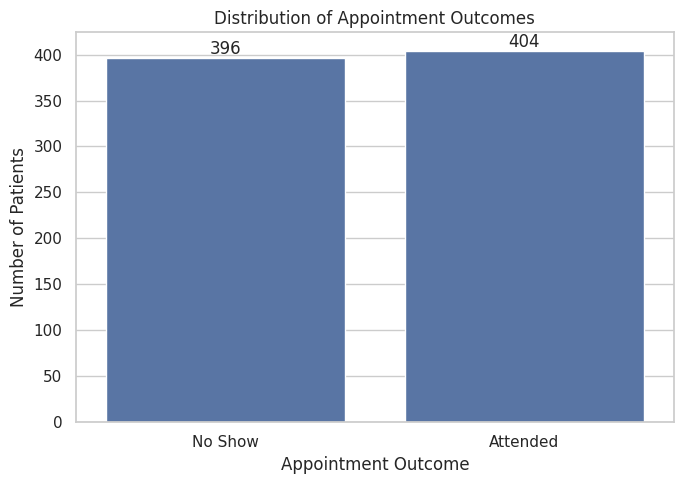

In [10]:
df["no_show_label"] = df["no_show"].map({
    0: "Attended",
    1: "No Show"
})

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="no_show_label"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Appointment Outcomes")
plt.xlabel("Appointment Outcome")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

# Numerical feature histograms

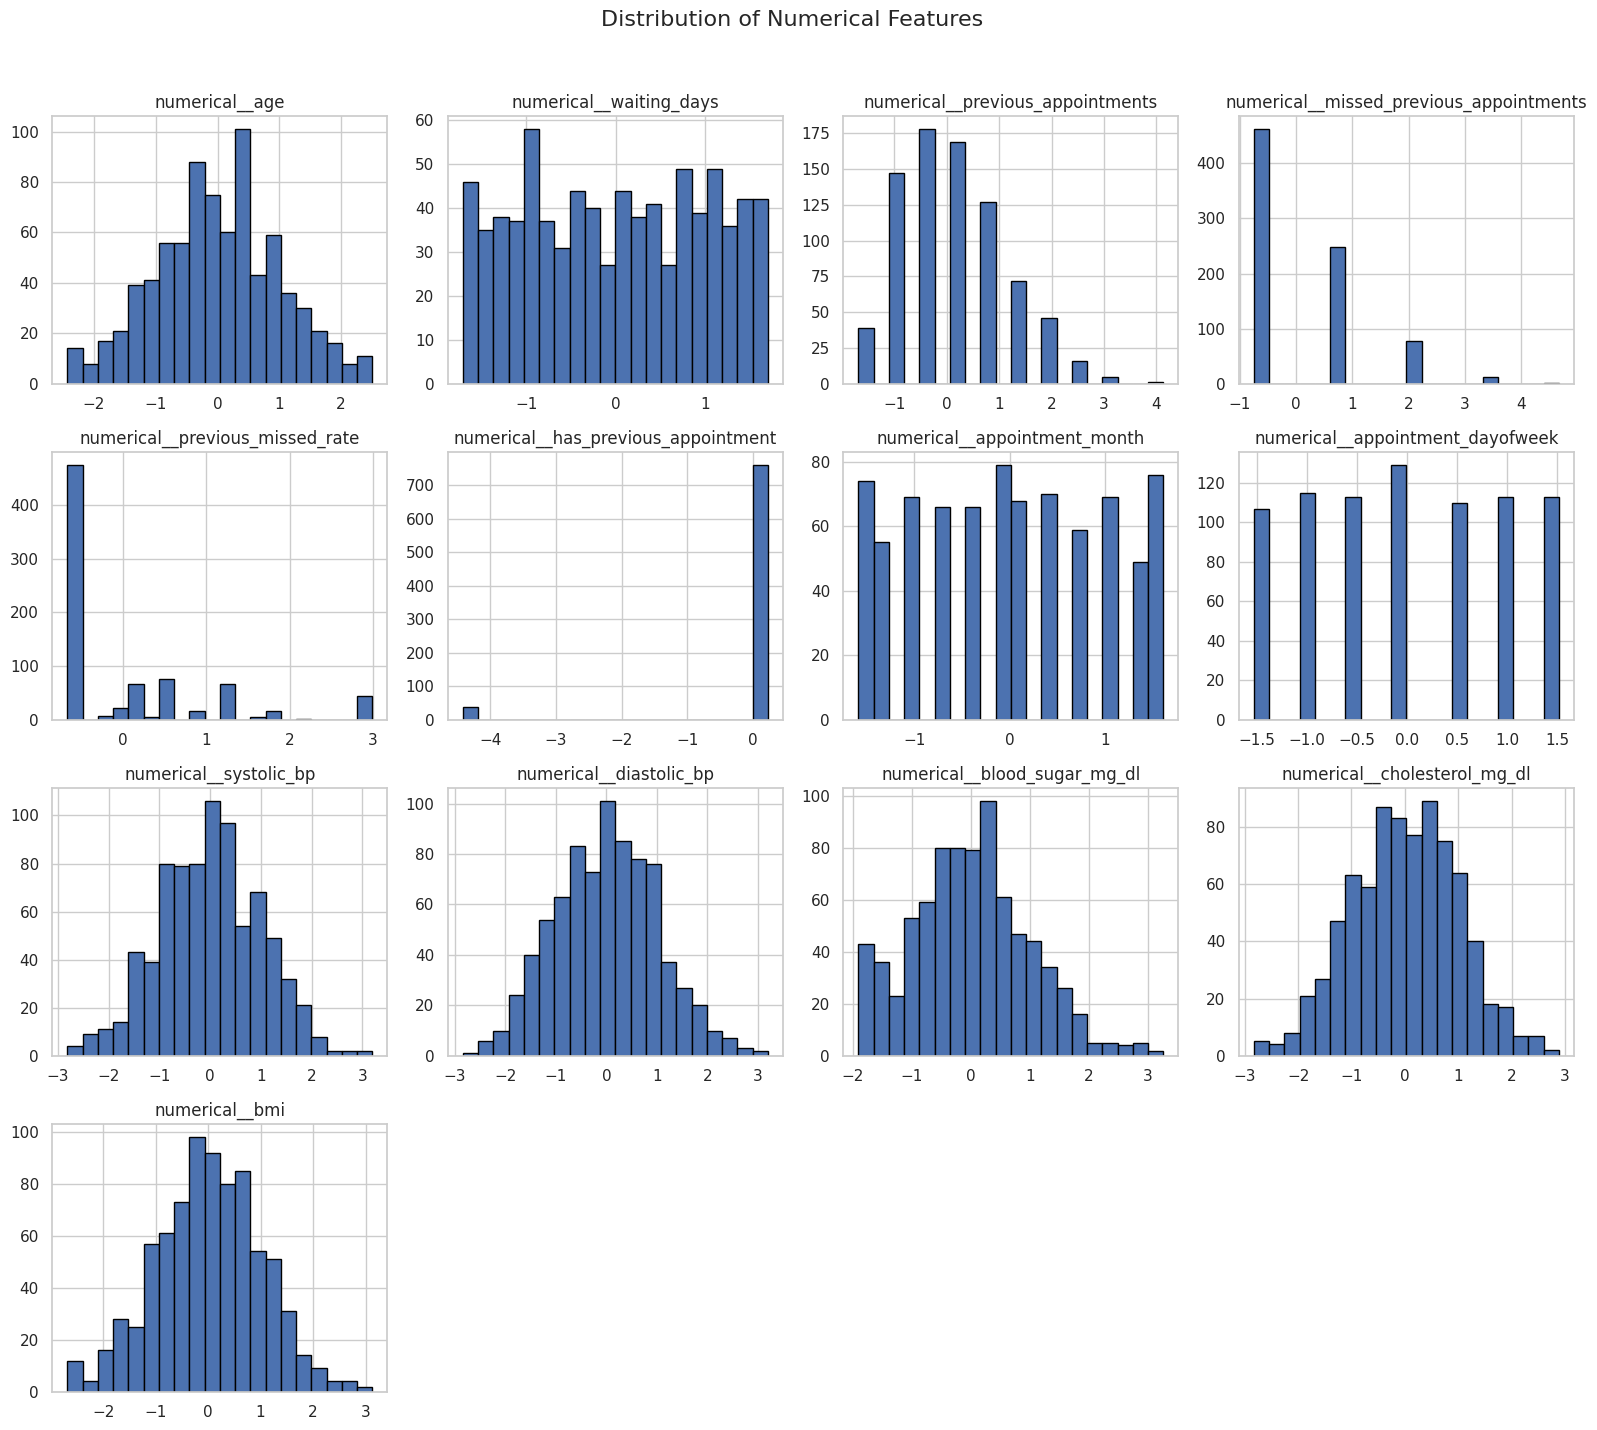

In [11]:
df[numerical_features].hist(
    figsize=(16, 14),
    bins=20,
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

# Better histograms comparing the target

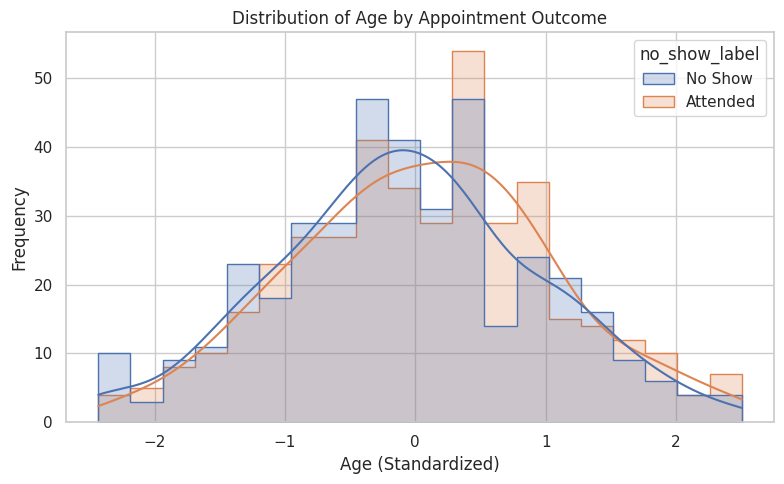

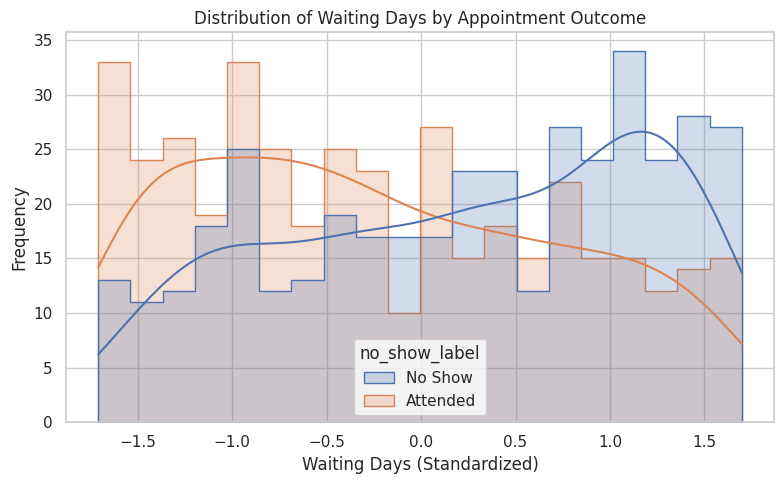

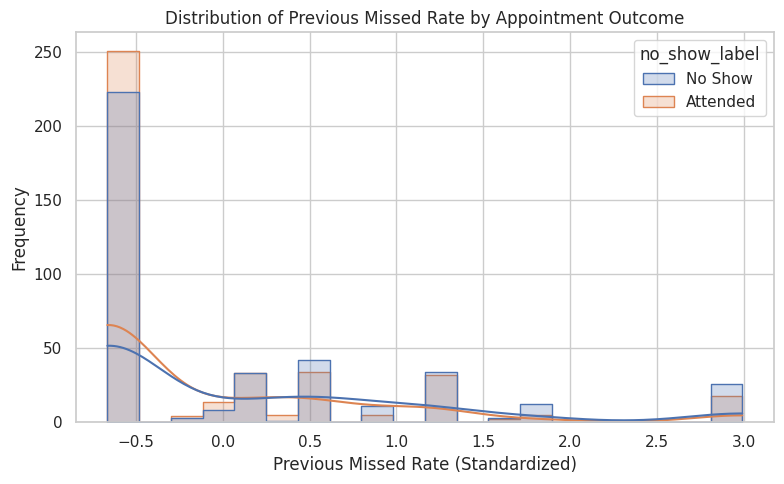

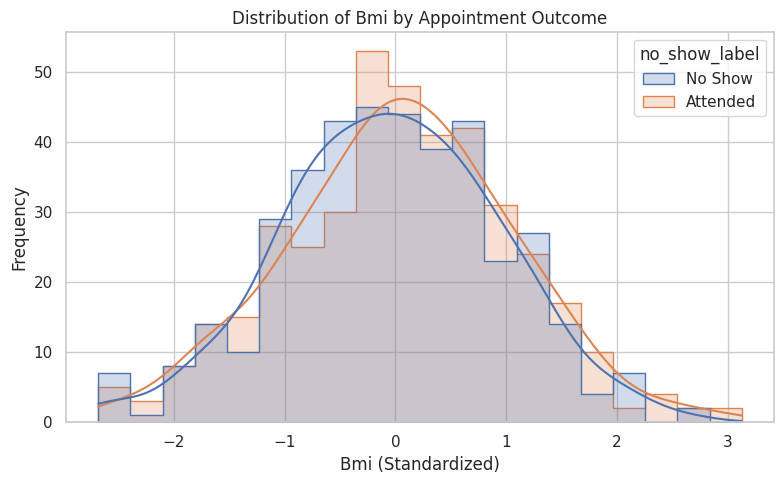

In [12]:
selected_features = [
    "numerical__age",
    "numerical__waiting_days",
    "numerical__previous_missed_rate",
    "numerical__bmi"
]

for feature in selected_features:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        hue="no_show_label",
        bins=20,
        kde=True,
        element="step"
    )

    clean_name = (
        feature
        .replace("numerical__", "")
        .replace("_", " ")
        .title()
    )

    plt.title(
        f"Distribution of {clean_name} by Appointment Outcome"
    )

    plt.xlabel(f"{clean_name} (Standardized)")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Boxplots

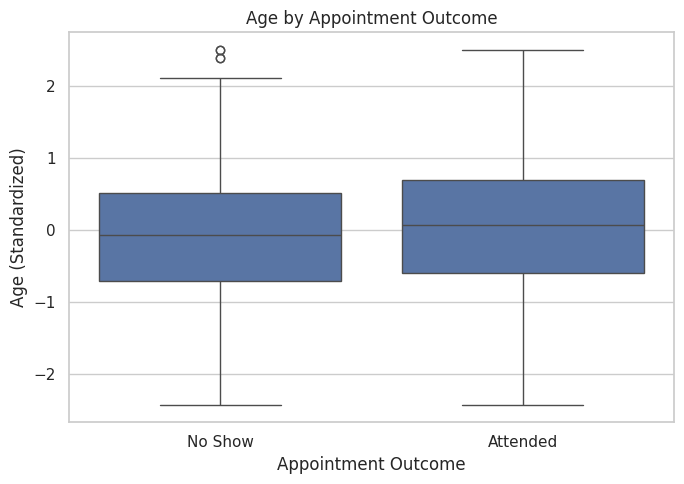

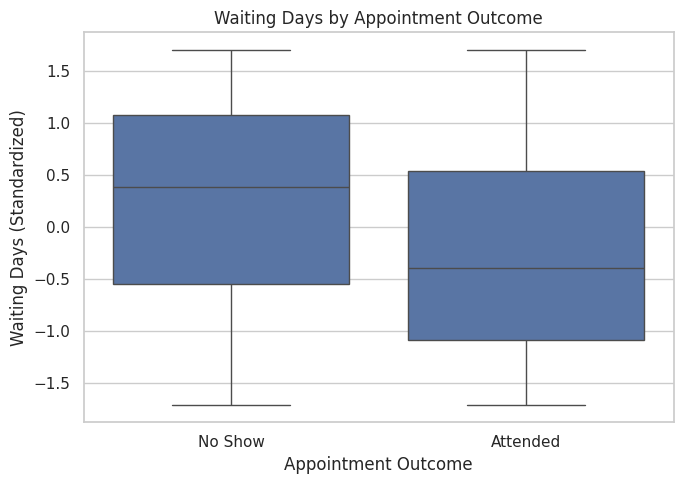

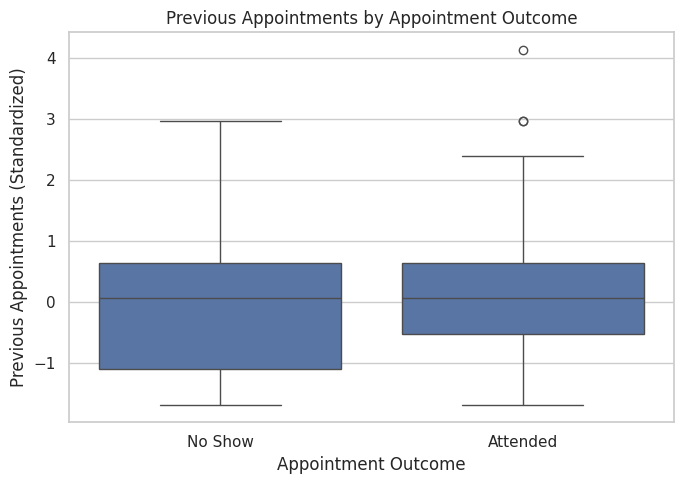

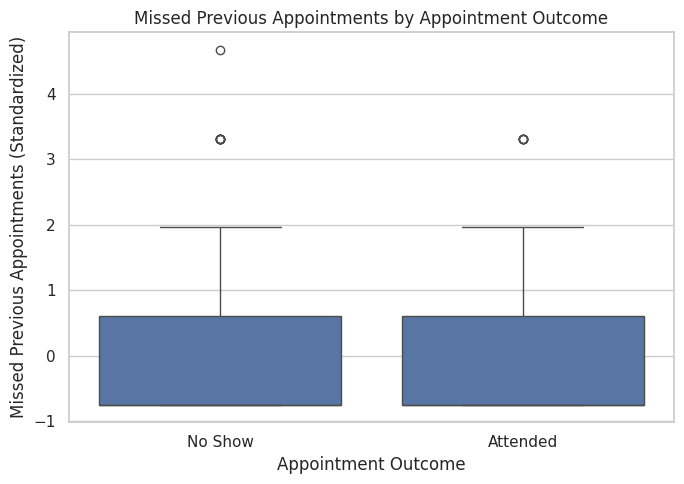

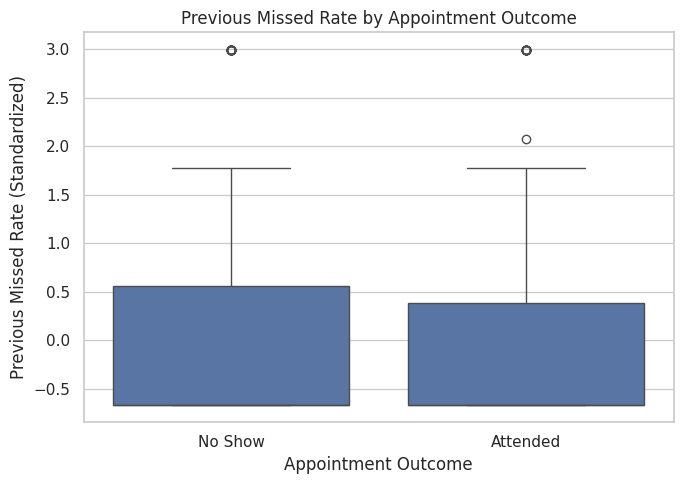

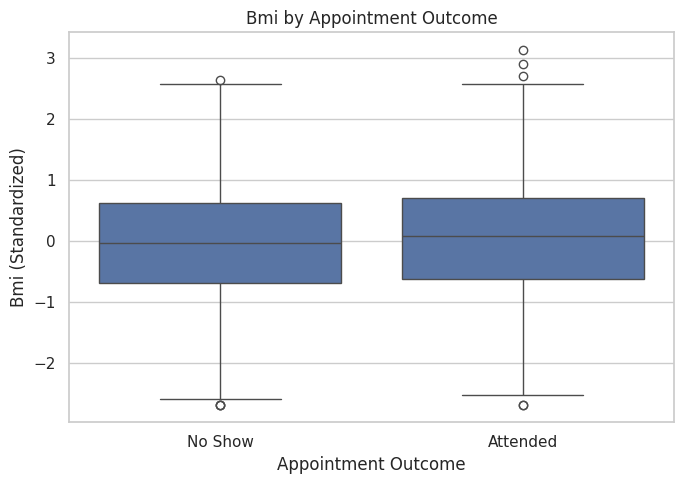

In [13]:
boxplot_features = [
    "numerical__age",
    "numerical__waiting_days",
    "numerical__previous_appointments",
    "numerical__missed_previous_appointments",
    "numerical__previous_missed_rate",
    "numerical__bmi"
]

for feature in boxplot_features:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="no_show_label",
        y=feature
    )

    clean_name = (
        feature
        .replace("numerical__", "")
        .replace("_", " ")
        .title()
    )

    plt.title(
        f"{clean_name} by Appointment Outcome"
    )

    plt.xlabel("Appointment Outcome")
    plt.ylabel(f"{clean_name} (Standardized)")

    plt.tight_layout()
    plt.show()

# Correlation analysis

In [15]:
correlation_features = numerical_features + ["no_show"]

correlation_matrix = (
    df[correlation_features]
    .corr()
)

correlation_matrix.round(2)

,numerical__age,numerical__waiting_days,numerical__previous_appointments,numerical__missed_previous_appointments,numerical__previous_missed_rate,numerical__has_previous_appointment,numerical__appointment_month,numerical__appointment_dayofweek,numerical__systolic_bp,numerical__diastolic_bp,numerical__blood_sugar_mg_dl,numerical__cholesterol_mg_dl,numerical__bmi,no_show
numerical__age,1.00,-0.02,0.03,-0.04,-0.06,-0.04,-0.01,-0.04,0.22,0.12,0.07,0.19,0.13,-0.06
numerical__waiting_days,-0.02,1.00,0.06,-0.01,-0.02,0.07,-0.00,0.01,0.03,-0.07,0.06,-0.03,0.04,0.23
numerical__previous_appointments,0.03,0.06,1.00,0.37,0.02,0.38,0.01,-0.01,0.01,0.01,0.00,0.01,0.04,-0.10
numerical__missed_previous_appointments,-0.04,-0.01,0.37,1.00,0.78,0.08,0.01,-0.05,0.01,-0.00,0.07,0.01,0.00,0.07
numerical__previous_missed_rate,-0.06,-0.02,0.02,0.78,1.00,0.15,0.01,-0.07,0.02,-0.07,0.06,-0.04,-0.00,0.08
numerical__has_previous_appointment,-0.04,0.07,0.38,0.08,0.15,1.00,-0.02,0.03,0.00,-0.06,0.04,-0.03,0.04,0.03
numerical__appointment_month,-0.01,-0.00,0.01,0.01,0.01,-0.02,1.00,-0.01,-0.05,0.06,-0.01,-0.01,-0.02,0.02
numerical__appointment_dayofweek,-0.04,0.01,-0.01,-0.05,-0.07,0.03,-0.01,1.00,-0.03,0.02,-0.00,-0.02,-0.04,0.08
numerical__systolic_bp,0.22,0.03,0.01,0.01,0.02,0.00,-0.05,-0.03,1.00,0.08,0.04,0.03,0.01,0.01
numerical__diastolic_bp,0.12,-0.07,0.01,-0.00,-0.07,-0.06,0.06,0.02,0.08,1.00,-0.00,0.01,0.02,-0.03


# Correlation heatmap

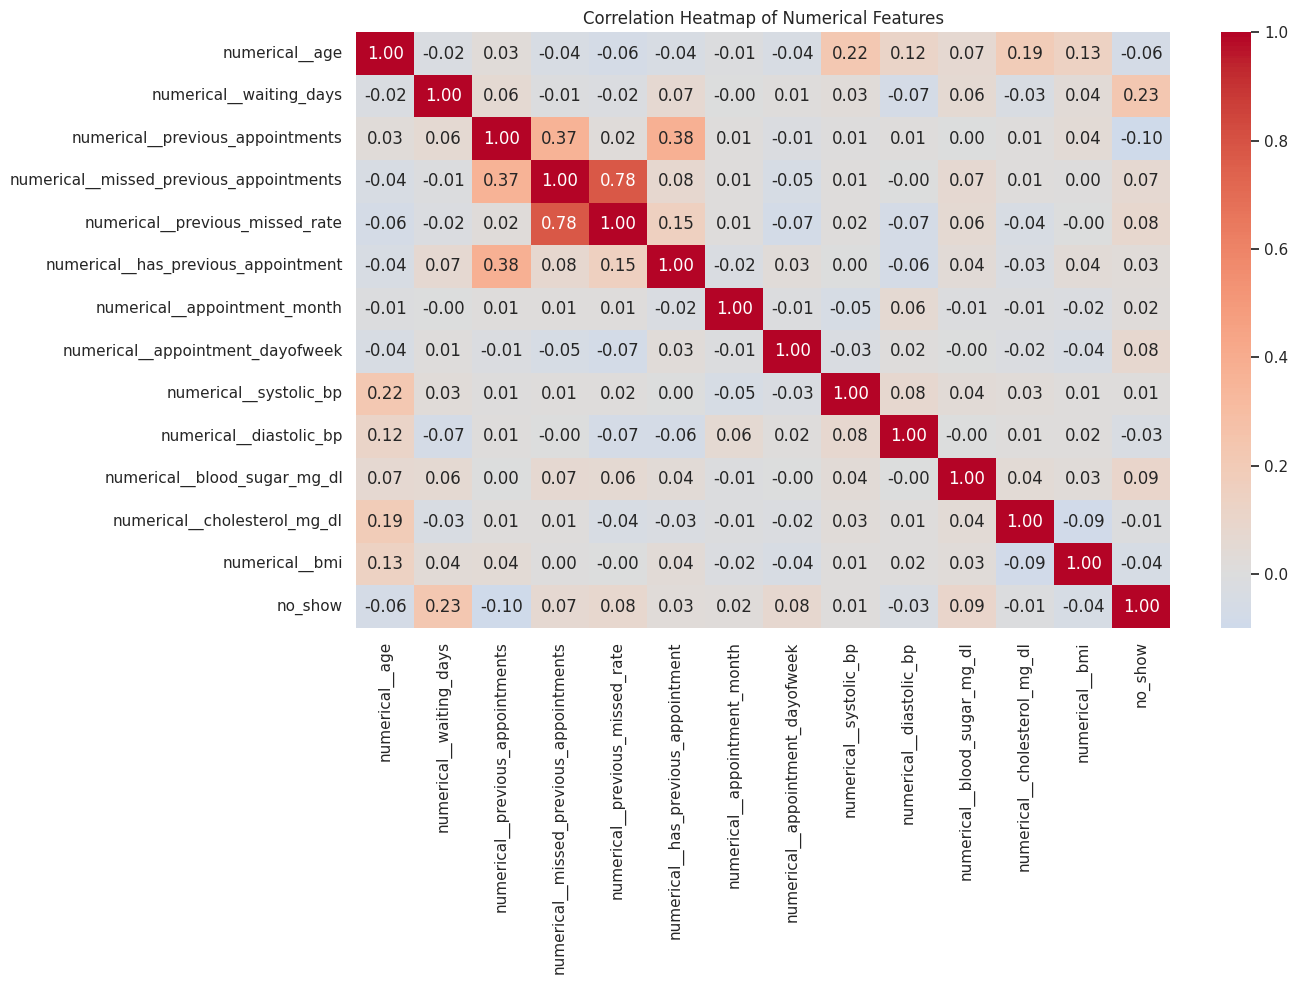

In [16]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Heatmap of Numerical Features"
)

plt.tight_layout()
plt.show()

# Correlation with no_show

In [17]:
target_correlations = (
    correlation_matrix["no_show"]
    .drop("no_show")
    .sort_values(
        key=abs,
        ascending=False
    )
)

target_correlations.to_frame(
    name="Correlation with No Show"
).round(3)

,Correlation with No Show
numerical__waiting_days,0.233
numerical__previous_appointments,-0.099
numerical__blood_sugar_mg_dl,0.095
numerical__previous_missed_rate,0.082
numerical__appointment_dayofweek,0.081
numerical__missed_previous_appointments,0.068
numerical__age,-0.065
numerical__bmi,-0.044
numerical__diastolic_bp,-0.034
numerical__has_previous_appointment,0.027


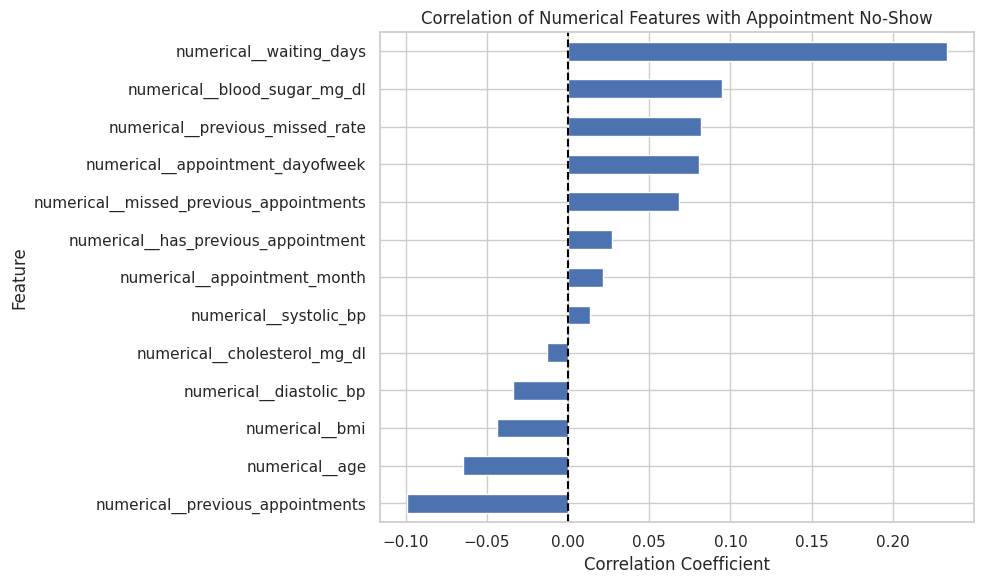

In [18]:
plt.figure(figsize=(10, 6))

target_correlations.sort_values().plot(
    kind="barh"
)

plt.axvline(
    x=0,
    color="black",
    linestyle="--"
)

plt.title(
    "Correlation of Numerical Features with Appointment No-Show"
)

plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# Scatterplot 1 — waiting days vs previous missed rate

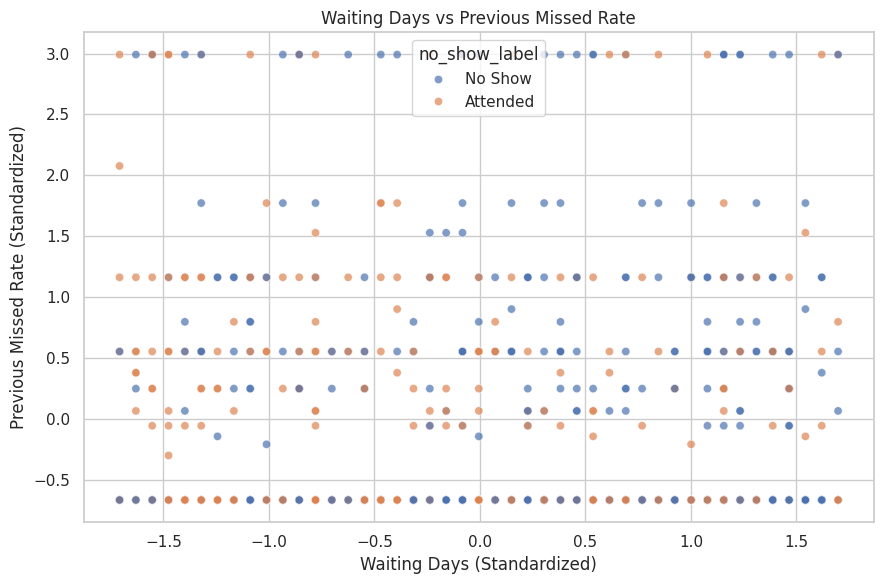

In [19]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="numerical__waiting_days",
    y="numerical__previous_missed_rate",
    hue="no_show_label",
    alpha=0.7
)

plt.title(
    "Waiting Days vs Previous Missed Rate"
)

plt.xlabel("Waiting Days (Standardized)")
plt.ylabel("Previous Missed Rate (Standardized)")

plt.tight_layout()
plt.show()

# Scatterplot 2 — previous appointments vs missed appointments

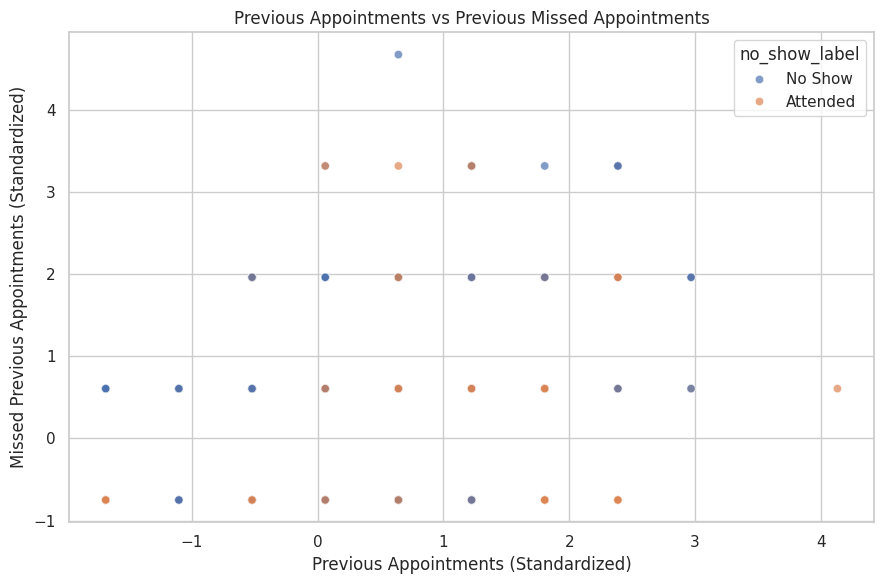

In [20]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="numerical__previous_appointments",
    y="numerical__missed_previous_appointments",
    hue="no_show_label",
    alpha=0.7
)

plt.title(
    "Previous Appointments vs Previous Missed Appointments"
)

plt.xlabel(
    "Previous Appointments (Standardized)"
)

plt.ylabel(
    "Missed Previous Appointments (Standardized)"
)

plt.tight_layout()
plt.show()

# Scatterplot 3 — Age vs BMI

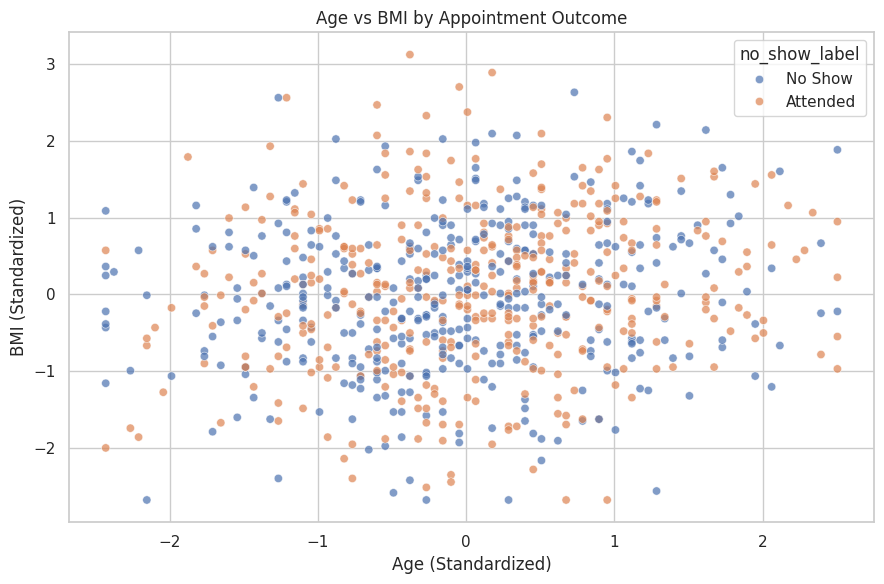

In [21]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="numerical__age",
    y="numerical__bmi",
    hue="no_show_label",
    alpha=0.7
)

plt.title(
    "Age vs BMI by Appointment Outcome"
)

plt.xlabel("Age (Standardized)")
plt.ylabel("BMI (Standardized)")

plt.tight_layout()
plt.show()

# Compare numerical features between classes

In [22]:
group_comparison = (
    df
    .groupby("no_show_label")[numerical_features]
    .mean()
    .T
)

group_comparison.round(3)

no_show_label,Attended,No Show
numerical__age,0.064,-0.065
numerical__waiting_days,-0.231,0.236
numerical__previous_appointments,0.098,-0.100
numerical__missed_previous_appointments,-0.068,0.069
numerical__previous_missed_rate,-0.081,0.083
numerical__has_previous_appointment,-0.026,0.027
numerical__appointment_month,-0.021,0.022
numerical__appointment_dayofweek,-0.080,0.081
numerical__systolic_bp,-0.013,0.013
numerical__diastolic_bp,0.033,-0.034


# Categorical pattern discovery

In [23]:
gender_columns = [
    "categorical__gender_Female",
    "categorical__gender_Male"
]

for col in gender_columns:

    category_name = (
        col
        .replace("categorical__gender_", "")
    )

    subset = df[df[col] == 1]

    no_show_rate = (
        subset["no_show"].mean() * 100
    )

    print(
        f"{category_name}: "
        f"{no_show_rate:.2f}% no-show rate "
        f"(n={len(subset)})"
    )

Female: 48.87% no-show rate (n=399)
Male: 50.12% no-show rate (n=401)


# Department analysis

In [24]:
department_columns = [
    col for col in df.columns
    if col.startswith("categorical__department_")
]

department_results = []

for col in department_columns:

    department = col.replace(
        "categorical__department_",
        ""
    )

    subset = df[df[col] == 1]

    department_results.append({
        "Department": department,
        "Number of Appointments": len(subset),
        "No Show Rate (%)":
            subset["no_show"].mean() * 100
    })

department_results = pd.DataFrame(
    department_results
).sort_values(
    "No Show Rate (%)",
    ascending=False
)

department_results.round(2)

,Department,Number of Appointments,No Show Rate (%)
3,Neurology,117,58.97
0,Cardiology,126,52.38
5,Pediatrics,118,48.31
1,General Medicine,127,48.03
2,Laboratory Services,95,47.37
6,Radiology,105,45.71
4,Orthopedics,112,44.64


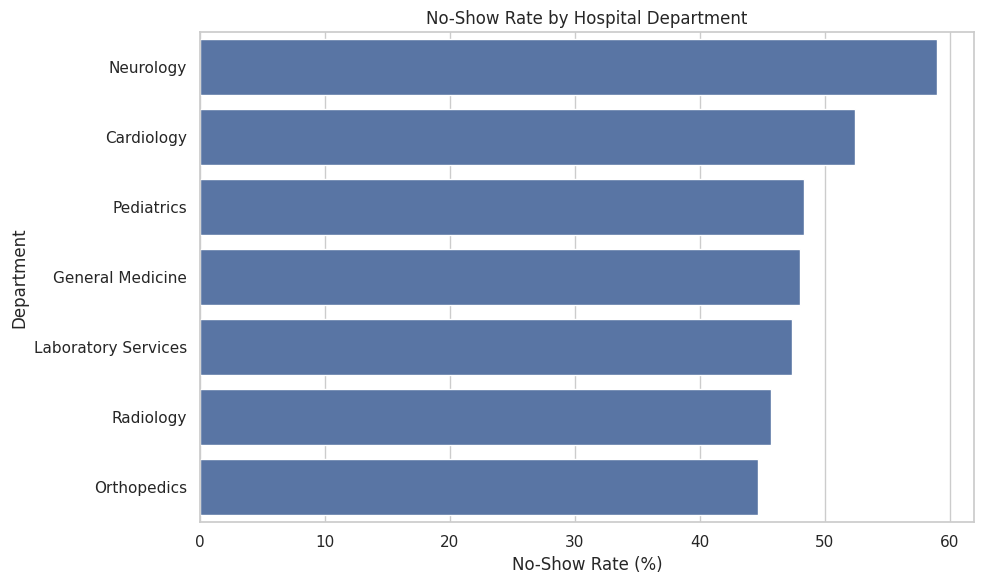

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=department_results,
    x="No Show Rate (%)",
    y="Department"
)

plt.title(
    "No-Show Rate by Hospital Department"
)

plt.xlabel("No-Show Rate (%)")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

# Diagnosis analysis

In [26]:
diagnosis_columns = [
    col for col in df.columns
    if col.startswith("categorical__diagnosis_")
]

diagnosis_results = []

for col in diagnosis_columns:

    diagnosis = col.replace(
        "categorical__diagnosis_",
        ""
    )

    subset = df[df[col] == 1]

    diagnosis_results.append({
        "Diagnosis": diagnosis,
        "Number of Patients": len(subset),
        "No Show Rate (%)":
            subset["no_show"].mean() * 100
    })

diagnosis_results = pd.DataFrame(
    diagnosis_results
).sort_values(
    "No Show Rate (%)",
    ascending=False
)

diagnosis_results.round(2)

,Diagnosis,Number of Patients,No Show Rate (%)
2,Chest Pain,63,60.32
0,Asthma,76,56.58
1,Back Pain,80,56.25
5,Fracture,85,51.76
9,Pneumonia,94,48.94
8,Migraine,88,48.86
3,Diabetes,78,47.44
7,Kidney Infection,82,43.90
6,Hypertension,72,43.06
4,Fever,82,40.24


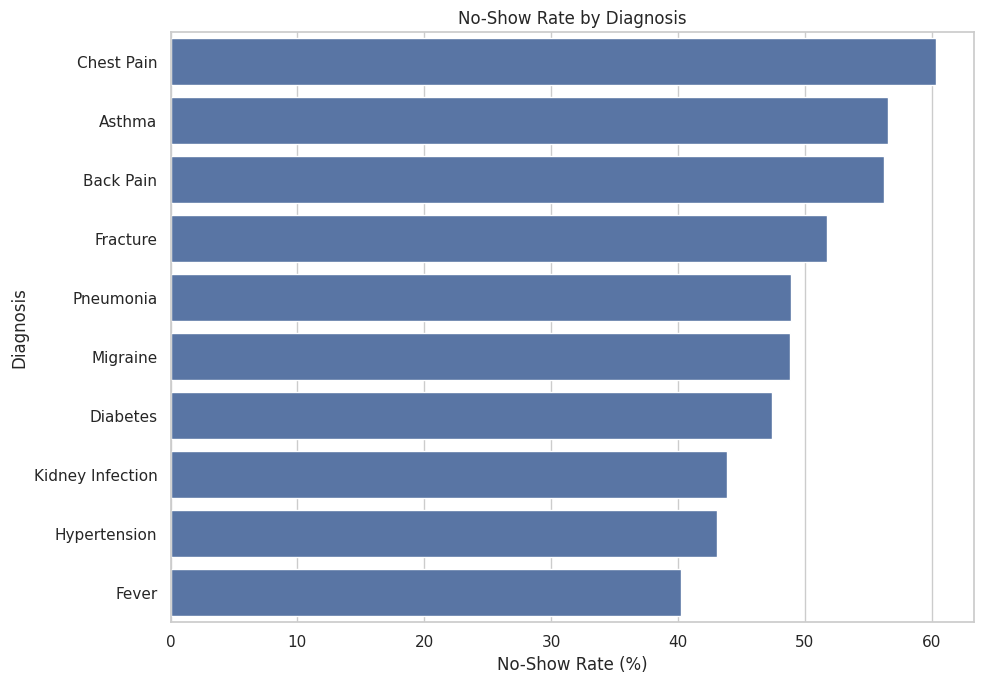

In [27]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=diagnosis_results,
    x="No Show Rate (%)",
    y="Diagnosis"
)

plt.title("No-Show Rate by Diagnosis")

plt.xlabel("No-Show Rate (%)")
plt.ylabel("Diagnosis")

plt.tight_layout()
plt.show()

# Blood pressure category analysis

In [28]:
bp_columns = [
    col for col in df.columns
    if col.startswith(
        "categorical__bp_category_"
    )
]

bp_results = []

for col in bp_columns:

    category = col.replace(
        "categorical__bp_category_",
        ""
    )

    subset = df[df[col] == 1]

    bp_results.append({
        "BP Category": category,
        "Number of Patients": len(subset),
        "No Show Rate (%)":
            subset["no_show"].mean() * 100
    })

bp_results = pd.DataFrame(bp_results)

bp_results.round(2)

,BP Category,Number of Patients,No Show Rate (%)
0,Elevated,101,46.53
1,High,538,51.12
2,Normal,138,50.00
3,Very High,23,21.74


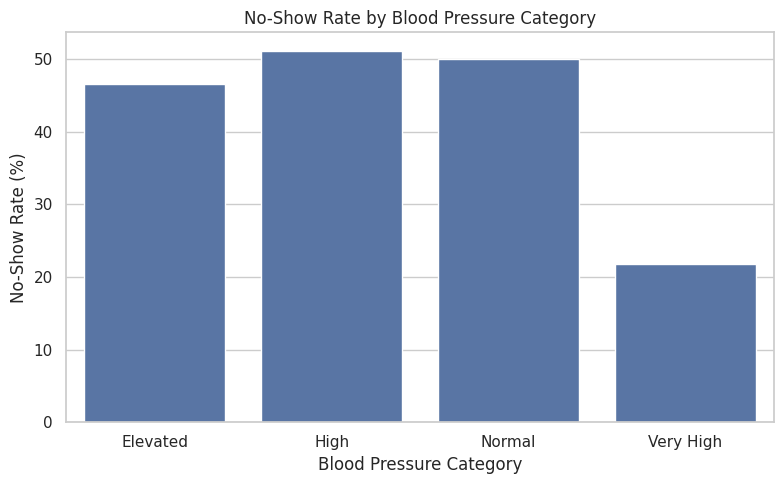

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=bp_results,
    x="BP Category",
    y="No Show Rate (%)"
)

plt.title(
    "No-Show Rate by Blood Pressure Category"
)

plt.xlabel("Blood Pressure Category")
plt.ylabel("No-Show Rate (%)")

plt.tight_layout()
plt.show()

# Full correlation heatmap including encoded features

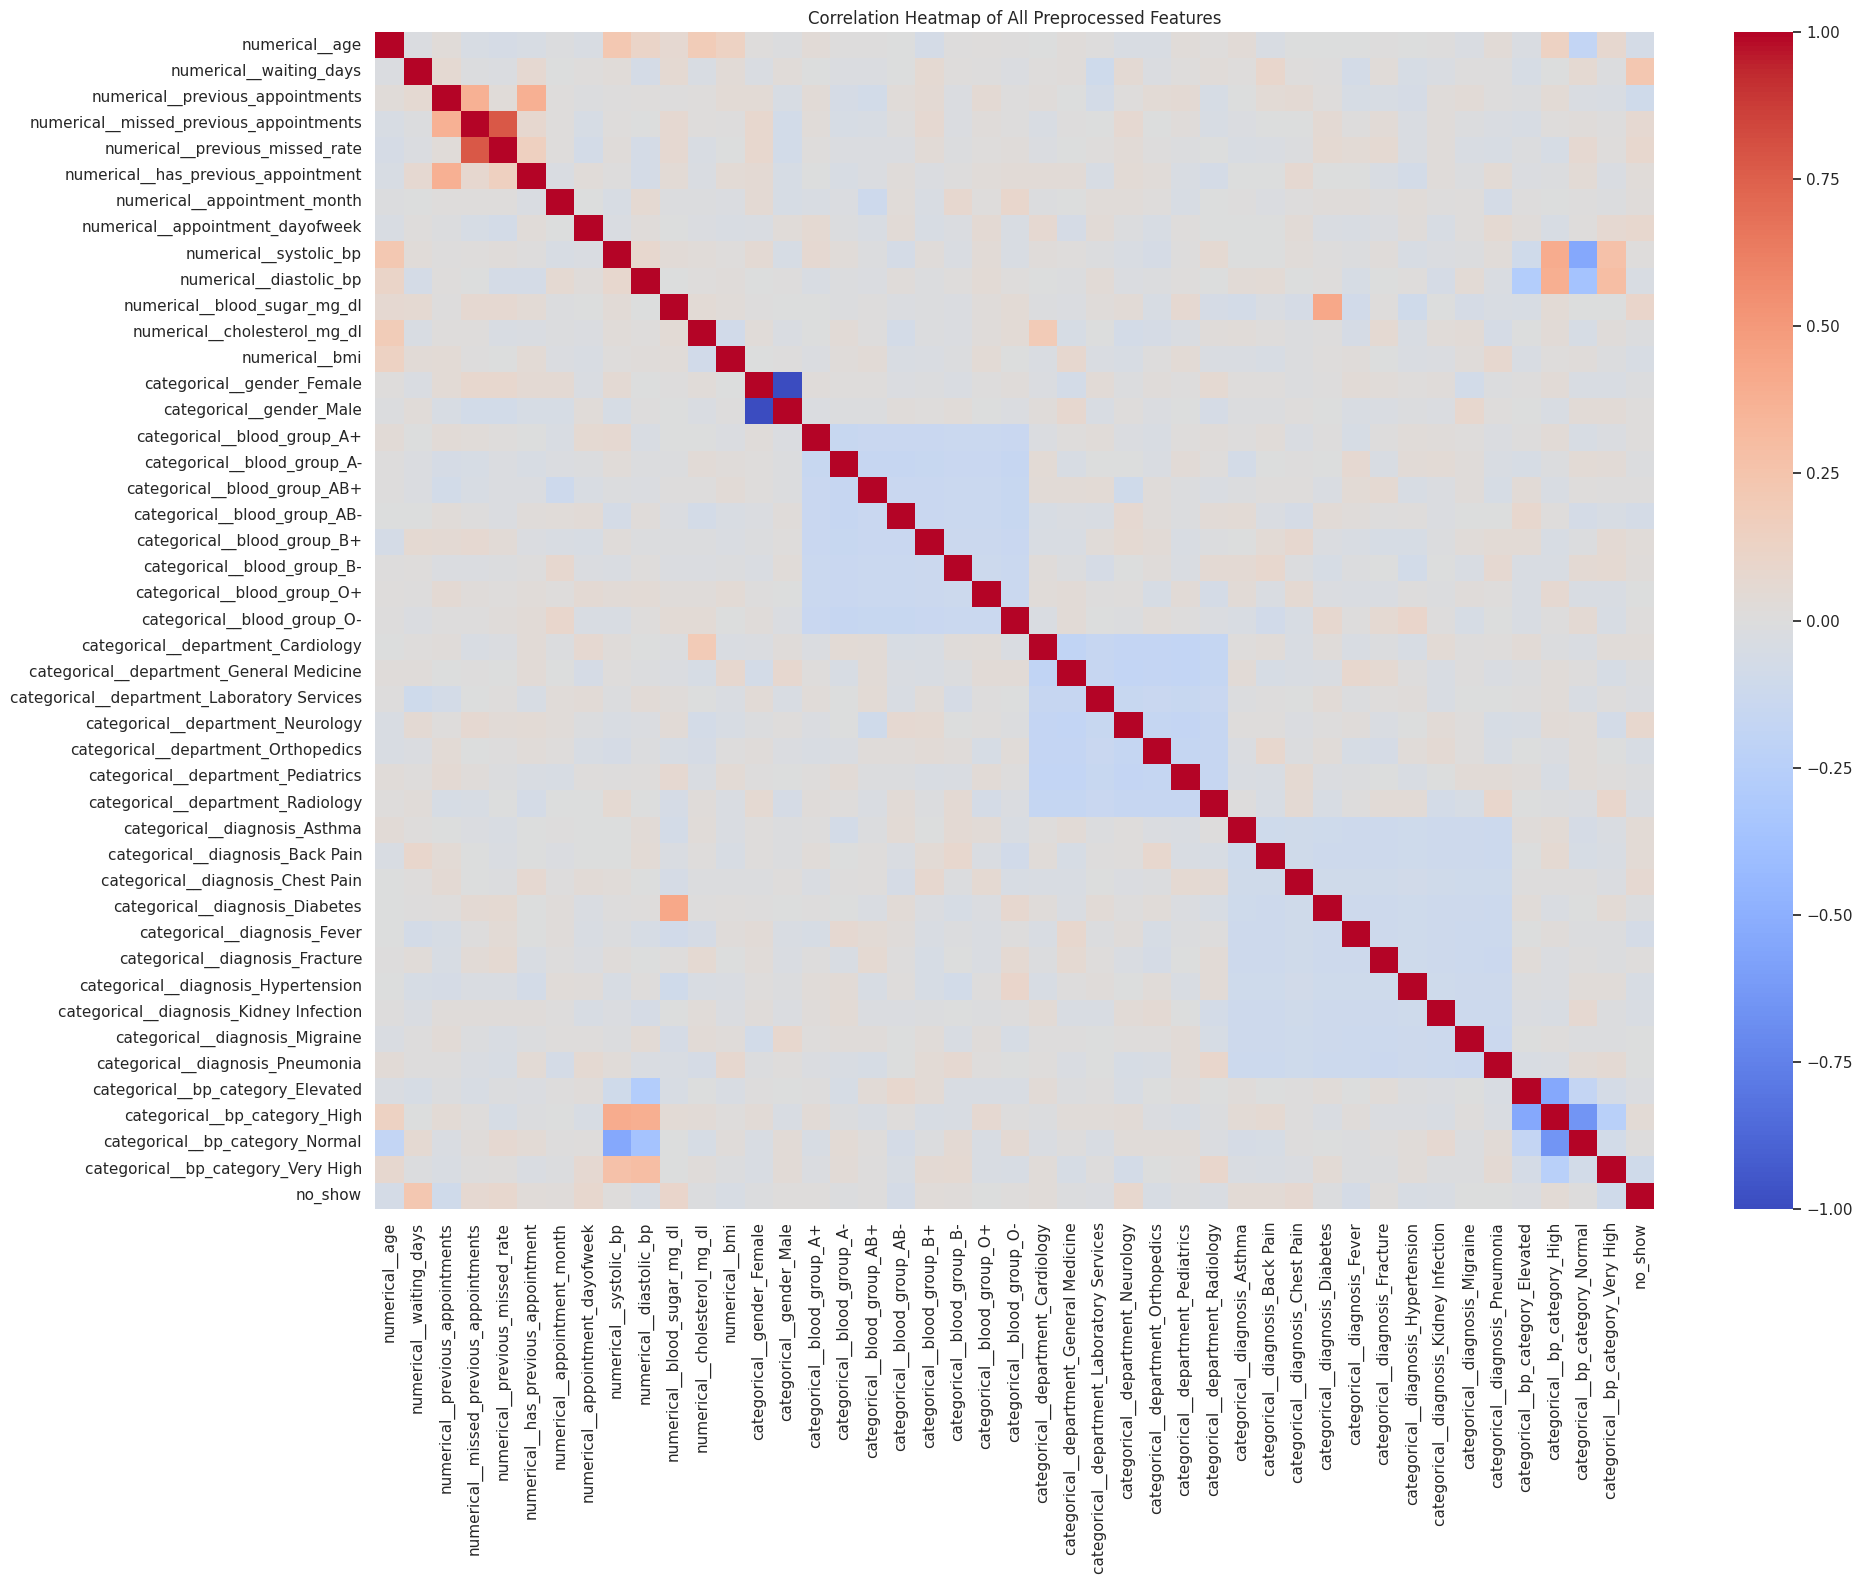

In [30]:
all_numeric_df = df.drop(
    columns=["no_show_label"],
    errors="ignore"
)

plt.figure(figsize=(20, 16))

sns.heatmap(
    all_numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Heatmap of All Preprocessed Features"
)

plt.tight_layout()
plt.show()

# Find the strongest relationships with target from ALL 44 features

In [31]:
all_correlations = (
    df
    .drop(columns=["no_show_label"], errors="ignore")
    .corr()["no_show"]
    .drop("no_show")
    .sort_values(
        key=abs,
        ascending=False
    )
)

all_correlations.head(15)

,no_show
numerical__waiting_days,0.233325
numerical__previous_appointments,-0.099443
categorical__bp_category_Very High,-0.095530
numerical__blood_sugar_mg_dl,0.094538
numerical__previous_missed_rate,0.081699
numerical__appointment_dayofweek,0.080526
categorical__department_Neurology,0.078430
numerical__missed_previous_appointments,0.068459
categorical__blood_group_AB-,-0.067071
numerical__age,-0.064773


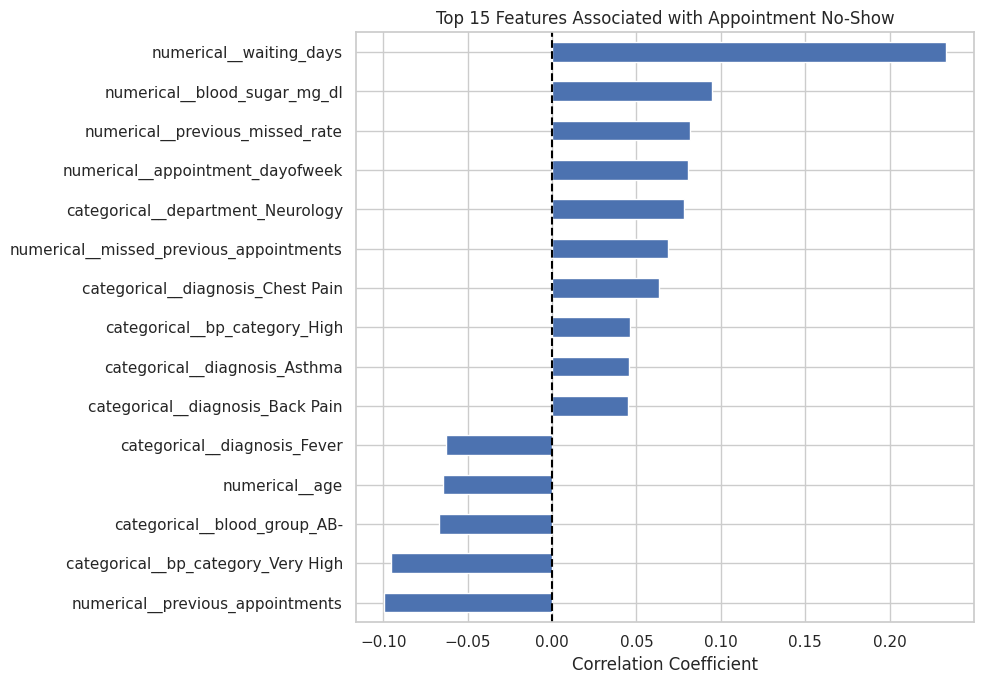

In [32]:
top_15 = all_correlations.head(15)

plt.figure(figsize=(10, 7))

top_15.sort_values().plot(
    kind="barh"
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.title(
    "Top 15 Features Associated with Appointment No-Show"
)

plt.xlabel("Correlation Coefficient")

plt.tight_layout()
plt.show()

# New Section